# Phase 3 - graph

Building out the LangGraph orchestration loop for Phase 3. Starts with item 4's skeleton (`docs/build-order.md`) and evolves through the rest of Phase 3 as later items land - one notebook, not a new one per item.

Section order: state/reducers, then node functions, then routing functions, then the graph itself.

## Imports & setup

Requires the MCP server running separately first: `uv run python -c "from app.mcp_server.server import mcp; import uvicorn; uvicorn.run(mcp.http_app(), host='127.0.0.1', port=8001)"`

In [1]:
import sys
sys.path.insert(0, "..")

import os
import uuid
import json
import asyncio
from datetime import datetime, timezone
from typing import Annotated, TypedDict

from langchain_core.messages import AIMessage, BaseMessage, SystemMessage, HumanMessage, ToolMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from langchain_mcp_adapters.client import MultiServerMCPClient

from app.config import MODEL, get_secret, GCP_PROJECT_ID
from app.telemetry.writer import build_telemetry_row, write_telemetry_row
from app.orchestrator.context import get_static_context

from IPython.display import Markdown, display

os.environ["ANTHROPIC_API_KEY"] = get_secret("anthropic-api-key", GCP_PROJECT_ID)

MAX_ANSWER_CHARS = 6000
MAX_LENGTH_RETRIES = 2
MAX_VERIFY_RETRIES = 2

SYSTEM_MESSAGE = SystemMessage(content=get_static_context())

mcp_client = MultiServerMCPClient({
    "analytics": {"transport": "streamable_http", "url": "http://127.0.0.1:8001/mcp"},
})
_tools = await mcp_client.get_tools()
MCP_TOOLS = {t.name: t for t in _tools}


def check_answer_length(answer_markdown: str) -> bool:
    return len(answer_markdown) <= MAX_ANSWER_CHARS


print("MCP tools loaded:", list(MCP_TOOLS))

MCP tools loaded: ['ping']


## State & reducers

In [2]:
class ToolCallRecord(TypedDict):
    id: str
    name: str
    args: dict
    query_text: str | None  # args["query"] or args["dax"] -- SQL/DAX only, else None
    result: list[dict] | str
    success: bool
    error: str | None
    started_at: datetime
    completed_at: datetime


class TurnError(TypedDict):
    stage: str
    error_type: str
    message: str
    occurred_at: datetime
    tool_call_id: str | None  # matches ToolCallRecord.id

#Append reducer
def append_list(existing: list, new: list) -> list:
    """Accumulates a list across graph supersteps."""
    return existing + new

# State
class AgentState(TypedDict):
    # Set once, at invocation
    question: str
    conversation_id: str
    user_id: str
    turn_started_at: datetime
    filter_context: list[dict]
    active_page: str | None
    image_base64: str | None
    history_messages: list[BaseMessage]  # prior turns, reconstructed by the
                                         # gateway via build_history_messages()
                                         # (not built yet). Kept OUT of
                                         # `messages` -- that field gets
                                         # written back to Firestore per turn
                                         # (messages_to_dict(state["messages"])),
                                         # so mixing history into it would make
                                         # every stored turn recursively include
                                         # every prior one. Prepended at LLM call
                                         # time only, same as SYSTEM_MESSAGE.

    # Accumulated during the loop
    messages: Annotated[list[BaseMessage], add_messages]
    tool_calls: Annotated[list[ToolCallRecord], append_list]
    iteration_count: int

    # Separate retry budgets
    verification_retry_count: int
    length_retry_count: int

    verified: bool

    # Resource accumulators
    bytes_consumed: int
    prompt_tokens: int
    completion_tokens: int
    llm_calls: int

    errors: Annotated[list[TurnError], append_list]
    cancelled: bool

    # Guardrail outcomes
    needs_approval: bool
    pending_queries: list[dict]
    deferred_dax: list[dict]
    estimated_cost: str | None
    cost_cap_exceeded: bool
    iteration_cap_hit: bool

    # Building toward AgentResponse
    answer_markdown: str
    chart_url: str | None
    sources: list[str]


print("AgentState fields:", list(AgentState.__annotations__))
print("Total field count:", len(AgentState.__annotations__))

AgentState fields: ['question', 'conversation_id', 'user_id', 'turn_started_at', 'filter_context', 'active_page', 'image_base64', 'history_messages', 'messages', 'tool_calls', 'iteration_count', 'verification_retry_count', 'length_retry_count', 'verified', 'bytes_consumed', 'prompt_tokens', 'completion_tokens', 'llm_calls', 'errors', 'cancelled', 'needs_approval', 'pending_queries', 'deferred_dax', 'estimated_cost', 'cost_cap_exceeded', 'iteration_cap_hit', 'answer_markdown', 'chart_url', 'sources']
Total field count: 29


## `run_bigquery_sql` Tool

In [3]:
import concurrent.futures
from datetime import date, time
from decimal import Decimal

from google.api_core.exceptions import GoogleAPICallError
from google.cloud import bigquery
from langchain_core.tools import tool, ToolException
from pydantic import BaseModel

from app.config import BIGQUERY_ROW_CAP, BIGQUERY_TIMEOUT_SECONDS, MAX_BYTES_BILLED


class ToolError(ToolException):
    """Raised for an actionable, agent-facing tool failure. A ToolException
    subclass so handle_tool_error=True converts it into a ToolMessage"""


class BigQuerySqlArgs(BaseModel):
    query: str


bq_client = bigquery.Client(project=GCP_PROJECT_ID)


@tool(args_schema= BigQuerySqlArgs)
async def run_bigquery_sql(query: str) -> list[dict]:
    """Runs a SQL query against agent_safe (BigQuery) -- upstream/warehouse data:
    raw order and product features, pre-model. The only dataset this can reach
    (IAM-scoped).

    Guardrails: results cap at 1,000 rows -- filter or aggregate rather than
    relying on LIMIT, which reduces rows returned but not bytes scanned;
    queries scanning over 1 GiB fail; 40s timeout.
    """

    # bigquery.Client.query() is synchronous, run it in a thread to avoid blocking the event loop.
    def _run() -> list[dict]:
        job_config = bigquery.QueryJobConfig(maximum_bytes_billed=MAX_BYTES_BILLED)
        job = bq_client.query(query, job_config=job_config)
        try:
            # ONE call -- max_results here, not a second .result() call, which
            # would re-fetch from scratch and defeat the cap.
            rows = job.result(timeout=BIGQUERY_TIMEOUT_SECONDS, max_results=BIGQUERY_ROW_CAP)
        except concurrent.futures.TimeoutError:
            bq_client.cancel_job(job.job_id)
            raise ToolError(
                f"Query exceeded the {BIGQUERY_TIMEOUT_SECONDS}s timeout and was "
                "cancelled. Narrow the query (add a filter or aggregate) and try again.")
        except GoogleAPICallError as e:
            #Exceeds maximum_bytes_billed limit
            if any(err.get("reason") == "bytesBilledLimitExceeded" for err in e.errors):
                raise ToolError(
                    f"Query would scan more than the {MAX_BYTES_BILLED / 1024**3:.0f} GiB "
                    "safety limit. Add a filter, select fewer columns, or aggregate to "
                    "reduce the data scanned.")
            # Any other BigQuery-side failure (bad SQL, etc.)
            raise ToolError(f"BigQuery error: {e}")

        # total_rows is the query's true total, unaffected by max_results --
        # fail loudly rather than silently hand back a partial result.
        if rows.total_rows > BIGQUERY_ROW_CAP:
            raise ToolError(
                f"Query returned {BIGQUERY_ROW_CAP}+ rows. Add a filter or "
                "aggregate to narrow it.")

        #Future insurance gaurd if date, time, or Decimal types are returned in the rows. Convert them to JSON-serializable types.
        #As written, build_tool_call_record() fails loudly if it encounters a non-serializable type.
        #This is intentional to ensure inconsistent, hard to work with, formats don't sneak through 
        # to Tool_Call_Record.result in telemetry

        def _convert(v):
            if isinstance(v, Decimal):
                return float(v)
            if isinstance(v, (date, time)):
                return v.isoformat()
            return v

        return [
            {k: _convert(v) for k, v in dict(row).items()}
            for row in rows
        ]
    return await asyncio.to_thread(_run)

#Ensures that ToolError exceptions raised in run_bigquery_sql() are converted to ToolMessage and handled by 
# the agent instead of crashing the agent.
run_bigquery_sql.handle_tool_error = True

In [4]:
from app.config import AGENT_SAFE_DATASET

query = f"""
SELECT department, ROUND(AVG(reordered), 4) AS reorder_rate, COUNT(*) AS n
FROM `{GCP_PROJECT_ID}.{AGENT_SAFE_DATASET}.product_order_analysis`
GROUP BY department
ORDER BY reorder_rate DESC
LIMIT 5
"""

result = await run_bigquery_sql.ainvoke({"query": query})
print(result)

[{'department': 'dairy eggs', 'reorder_rate': 0.6676, 'n': 551399}, {'department': 'beverages', 'reorder_rate': 0.659, 'n': 283342}, {'department': 'produce', 'reorder_rate': 0.649, 'n': 977542}, {'department': 'bakery', 'reorder_rate': 0.6273, 'n': 120849}, {'department': 'pets', 'reorder_rate': 0.6107, 'n': 11129}]


In [5]:
tool_call = {"name": "run_bigquery_sql", "args": {"query": query}, "id": "test-1", "type": "tool_call"}
msg = await run_bigquery_sql.ainvoke(tool_call)
print(type(msg).__name__, msg.tool_call_id)
print(msg.content)
msg

ToolMessage test-1
[{"department": "dairy eggs", "reorder_rate": 0.6676, "n": 551399}, {"department": "beverages", "reorder_rate": 0.659, "n": 283342}, {"department": "produce", "reorder_rate": 0.649, "n": 977542}, {"department": "bakery", "reorder_rate": 0.6273, "n": 120849}, {"department": "pets", "reorder_rate": 0.6107, "n": 11129}]


ToolMessage(content='[{"department": "dairy eggs", "reorder_rate": 0.6676, "n": 551399}, {"department": "beverages", "reorder_rate": 0.659, "n": 283342}, {"department": "produce", "reorder_rate": 0.649, "n": 977542}, {"department": "bakery", "reorder_rate": 0.6273, "n": 120849}, {"department": "pets", "reorder_rate": 0.6107, "n": 11129}]', name='run_bigquery_sql', tool_call_id='test-1')

## Node functions

Item 4's scope (`docs/build-order.md`) using the real `ping` tool already on the MCP server instead of an empty list, so `call_tool` gets exercised for real too. `agent` writes `answer_markdown` itself whenever it has no tool calls - no separate structured-output call. `verify` is a placeholder; real pooled-matching verification is item 6.

In [ ]:
from itertools import groupby
from operator import itemgetter

from app.config import ABSOLUTE_CAP, BIGQUERY_PRICE_PER_TIB, MAX_ITERATIONS

ALL_TOOLS = {**MCP_TOOLS, "run_bigquery_sql": run_bigquery_sql}

# Separate from FRIENDLY_TOOL_NAMES (.claude/rules/gateway.md): those are
# present-tense progress messages, these are past-tense badges. No tool jargon
# -- the reader is field-operations staff. "Model fields" is the SEMANTIC
# model's, not BigQuery's.
SOURCE_LABELS = {
    "run_bigquery_sql": "Query warehouse",
    "run_dax_query":    "Query dashboard",
    "get_measure_dax":  "Measure Lookup",
    "get_page_info":    "PBI page info",
    "list_repo_files":  "list code",
    "read_repo_file":   "Read code",
    "search_docs":      "Doc Search",
    "generate_chart":   "Create chart",
}


async def dry_run(query: str) -> int:
    """Prices a query without running it."""
    def _run() -> int:
        job = bq_client.query(query, job_config=bigquery.QueryJobConfig(dry_run=True))
        return job.total_bytes_processed
    return await asyncio.to_thread(_run)


def exceeds_absolute_cap(bytes_consumed: int, batch_bytes: int, cap: int = ABSOLUTE_CAP) -> bool:
    """True if dispatching this batch would push the turn's cumulative bytes at/over cap."""
    return bytes_consumed + batch_bytes >= cap


def format_cost(num_bytes: int) -> str:
    """Formats a byte count as a display dollar string -- decisions are made in bytes, this is display only."""
    return f"${(num_bytes / 1024**4) * BIGQUERY_PRICE_PER_TIB:.2f}"


def sum_token_usage(messages: list[BaseMessage]) -> tuple[int, int]:
    """Sums prompt/completion tokens across every AIMessage in this turn's
    messages -- agent-count-agnostic, so a future LLM-calling node besides
    agent_node is picked up automatically."""
    ai_messages = [m for m in messages if isinstance(m, AIMessage)]
    prompt_tokens = sum(m.usage_metadata["input_tokens"] for m in ai_messages)
    completion_tokens = sum(m.usage_metadata["output_tokens"] for m in ai_messages)
    return prompt_tokens, completion_tokens


def build_sources(tool_calls: list[ToolCallRecord]) -> list[str]:
    """Ordered source labels for successful calls, consecutive runs collapsed with a count."""
    ordered = sorted(tool_calls, key=itemgetter("started_at", "name"))
    names = [SOURCE_LABELS.get(tc["name"], tc["name"])
             for tc in ordered if tc["success"]]
    return [f"{name} ({n})" if (n := len(list(grp))) > 1 else name
            for name, grp in groupby(names)]


def build_tool_call_record(
    tc: dict, message: ToolMessage, started_at: datetime, completed_at: datetime
) -> ToolCallRecord:
    """Builds a ToolCallRecord from a dispatched tool call and its ToolMessage."""
    query_text = tc["args"].get("query") or tc["args"].get("dax")
    success = message.status != "error"
    if not success:
        return ToolCallRecord(
            id=tc["id"], name=tc["name"], args=tc["args"], query_text=query_text, result="",
            success=False, error=message.content,
            started_at=started_at, completed_at=completed_at,
        )

    #Handle different formats for MCP Tools and Langchain Tools. MCP Tools result lives in artifact as a dict,
    # Langchain Tools result is a JSON string in content. 
    result = message.artifact if message.artifact is not None else json.loads(message.content)
    return ToolCallRecord(
        id=tc["id"], name=tc["name"], args=tc["args"], query_text=query_text, result=result,
        success=True, error=None,
        started_at=started_at, completed_at=completed_at,
    )


def build_turn_error(
    stage: str, error_type: str, message: str, occurred_at: datetime, tool_call_id: str | None
) -> TurnError:
    """Builds a TurnError -- a node's guardrail violation (iteration_cap_hit,
    cost_cap_exceeded) or a real tool failure"""
    return TurnError(stage=stage, error_type=error_type, message=message,
                      occurred_at=occurred_at, tool_call_id=tool_call_id)


def iteration_cap_update(tool_calls: list[dict], iteration_count: int) -> dict:
    """State update for a turn that hit max_iterations -- declines every call
    in the batch, with a matching ToolCallRecord and TurnError for each."""
    started_at = datetime.now(timezone.utc)
    messages = [
        ToolMessage(
            content=(
                "Not executed -- this turn has reached its iteration limit. "
                "You cannot call any more tools. Provide the best answer you "
                "can with what you already have, and state plainly that this "
                "is a partial answer."),
            name=tc["name"], tool_call_id=tc["id"], status="error")
        for tc in tool_calls
    ]
    completed_at = datetime.now(timezone.utc)
    records = [
        build_tool_call_record(tc, msg, started_at, completed_at)
        for tc, msg in zip(tool_calls, messages)
    ]
    return {
        "messages": messages,
        "iteration_count": iteration_count + 1,
        "iteration_cap_hit": True,
        "tool_calls": records,
        "errors": [
            build_turn_error("call_tool", "iteration_cap_hit", r["error"], r["completed_at"], r["id"])
            for r in records
        ],
    }


async def agent_node(state: AgentState) -> dict:
    """Calls the LLM with tools bound. Emits tool calls, or writes answer_markdown."""
    model = ChatAnthropic(model=MODEL).bind_tools(list(ALL_TOOLS.values()), strict=True)
    response = await model.ainvoke([SYSTEM_MESSAGE, *state["history_messages"], *state["messages"]])
    update = {"messages": [response], "llm_calls": state["llm_calls"] + 1}
    if not response.tool_calls:
        update["answer_markdown"] = response.content
    return update


async def call_tool_node(state: AgentState) -> dict:
    """Dispatches this turn's tool calls under the iteration and cost-cap
    guardrails; records a ToolCallRecord and, for any declined or failed
    call, a matching TurnError."""
    tool_calls = state["messages"][-1].tool_calls

    if state["iteration_count"] >= MAX_ITERATIONS:
        return iteration_cap_update(tool_calls, state["iteration_count"])

    bq_calls = [tc for tc in tool_calls if tc["name"] == "run_bigquery_sql"]
    other_calls = [tc for tc in tool_calls if tc["name"] != "run_bigquery_sql"]

    batch_bytes = 0
    estimates: list[int] = []
    cost_cap_exceeded = False
    if bq_calls:
        estimates = await asyncio.gather(*[dry_run(tc["args"]["query"]) for tc in bq_calls])
        batch_bytes = sum(estimates)
        cost_cap_exceeded = exceeds_absolute_cap(state["bytes_consumed"], batch_bytes)

    other_started_at = datetime.now(timezone.utc)
    other_messages = await asyncio.gather(*[ALL_TOOLS[tc["name"]].ainvoke(tc) for tc in other_calls])
    other_completed_at = datetime.now(timezone.utc)

    bq_started_at = datetime.now(timezone.utc)
    if cost_cap_exceeded:
        bq_messages = [
            ToolMessage(
                content=(
                    f"Not executed -- this query would push the turn's total scanned "
                    f"data over the {ABSOLUTE_CAP / 1024**3:.0f} GiB limit. Try a "
                    "cheaper query, or provide the best answer you can with what you "
                    "already have and tell the user you hit the turn's cost limit."),
                name=tc["name"], tool_call_id=tc["id"], status="error")
            for tc in bq_calls
        ]
    else:
        bq_messages = await asyncio.gather(*[ALL_TOOLS[tc["name"]].ainvoke(tc) for tc in bq_calls])
    bq_completed_at = datetime.now(timezone.utc)

    # asyncio.gather() preserves input order in its results, so zip(calls, messages)
    # pairs each call with its own message correctly.
    bq_records = [
        build_tool_call_record(tc, msg, bq_started_at, bq_completed_at)
        for tc, msg in zip(bq_calls, bq_messages)
    ]
    other_records = [
        build_tool_call_record(tc, msg, other_started_at, other_completed_at)
        for tc, msg in zip(other_calls, other_messages)
    ]

    bq_error_type = "cost_cap_exceeded" if cost_cap_exceeded else "tool_error"
    errors = [
        build_turn_error("call_tool", bq_error_type, r["error"], r["completed_at"], r["id"])
        for r in bq_records if not r["success"]
    ] + [
        build_turn_error("call_tool", "tool_error", r["error"], r["completed_at"], r["id"])
        for r in other_records if not r["success"]
    ]

    # Only bill bytes for calls that actually ran to completion -- a query
    # that fails (MAX_BYTES_BILLED, timeout, bad SQL) was never billed by
    # BigQuery, so charging its dry-run estimate against bytes_consumed would
    # deplete the turn's budget for work that cost nothing.
    billed_bytes = 0 if cost_cap_exceeded else sum(
        est for est, r in zip(estimates, bq_records) if r["success"]
    )
    return {
        "messages": bq_messages + other_messages,
        "iteration_count": state["iteration_count"] + 1,
        "bytes_consumed": state["bytes_consumed"] + billed_bytes,
        "cost_cap_exceeded": cost_cap_exceeded,
        "estimated_cost": format_cost(batch_bytes) if cost_cap_exceeded else state["estimated_cost"],
        "tool_calls": bq_records + other_records,
        "errors": errors,
    }


async def check_length_node(state: AgentState) -> dict:
    """Checks answer_markdown length; on failure, requests a shorter answer."""
    if check_answer_length(state["answer_markdown"]):
        return {}
    return {
        "length_retry_count": state["length_retry_count"] + 1,
        "messages": [HumanMessage(content=(
            "Your answer is too long to display. Summarize the key findings "
            "concisely, or generate a chart instead of listing rows."))],
    }


async def verify_node(state: AgentState) -> dict:
    """Placeholder -- always verifies. Real checks land later."""
    return {"verified": True}


async def finalize_node(state: AgentState) -> dict:
    """Tallies token usage and sources, then builds and writes the telemetry row."""
    prompt_tokens, completion_tokens = sum_token_usage(state["messages"])
    sources = build_sources(state["tool_calls"])
    row = build_telemetry_row(
        conversation_id=state["conversation_id"],
        user_id=state["user_id"],
        question=state["question"],
        answer_markdown=state["answer_markdown"],
        turn_started_at=state["turn_started_at"],
        turn_completed_at=datetime.now(timezone.utc),
        filter_context=state["filter_context"],
        active_page=state["active_page"],
        tool_calls=state["tool_calls"],
        errors=state["errors"],
        prompt_tokens=prompt_tokens,
        completion_tokens=completion_tokens,
        llm_calls=state["llm_calls"],
        bytes_consumed=state["bytes_consumed"],
        iteration_count=state["iteration_count"],
        verified=state["verified"],
        verification_retry_count=state["verification_retry_count"],
        length_retry_count=state["length_retry_count"],
        needs_approval=state["needs_approval"],
        cost_cap_exceeded=state["cost_cap_exceeded"],
        cancelled=state["cancelled"],
        iteration_cap_hit=state["iteration_cap_hit"],
        estimated_cost=state["estimated_cost"],
        pending_queries=state["pending_queries"],
        deferred_dax=state["deferred_dax"],
        chart_url=state["chart_url"],
    )
    await write_telemetry_row(row)
    return {
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "sources": sources,
    }


print("5 nodes defined")

## Routing functions

In [7]:
def route_after_agent(state: AgentState) -> str:
    return "call_tool" if state["messages"][-1].tool_calls else "check_length"


def route_after_call_tool(state: AgentState) -> str:
    if state["cancelled"] or state["needs_approval"]:
        return "finalize"
    return "agent"   # also cost_cap_exceeded and iteration_cap_hit


def route_after_check_length(state: AgentState) -> str:
    if check_answer_length(state["answer_markdown"]):
        return "verify"
    if state["length_retry_count"] < MAX_LENGTH_RETRIES:
        return "agent"
    return "finalize"


def route_after_verify(state: AgentState) -> str:
    if state["verified"]:
        return "finalize"
    if state["verification_retry_count"] < MAX_VERIFY_RETRIES:
        return "agent"
    return "finalize"

## Graph

`route_entry`/`execute_approved` aren't built until item 11, so this graph starts at `agent` directly.

In [8]:
g = StateGraph(AgentState)
g.add_node("agent",        agent_node)
g.add_node("call_tool",    call_tool_node)
g.add_node("check_length", check_length_node)
g.add_node("verify",       verify_node)
g.add_node("finalize",     finalize_node)

g.add_edge(START, "agent")

# A plain list of names is sugar for the identity path_map ({name: name for
# name in [...]}) -- still needed for get_graph() to draw the real edges.
g.add_conditional_edges("agent", route_after_agent,
    ["call_tool", "check_length"])
g.add_conditional_edges("call_tool", route_after_call_tool,
    ["finalize", "agent"])
g.add_conditional_edges("check_length", route_after_check_length,
    ["verify", "agent", "finalize"])
g.add_conditional_edges("verify", route_after_verify,
    ["finalize", "agent"])

g.add_edge("finalize", END)
graph = g.compile()

print("graph compiled:", list(graph.get_graph().nodes))

graph compiled: ['__start__', 'agent', 'call_tool', 'check_length', 'verify', 'finalize', '__end__']


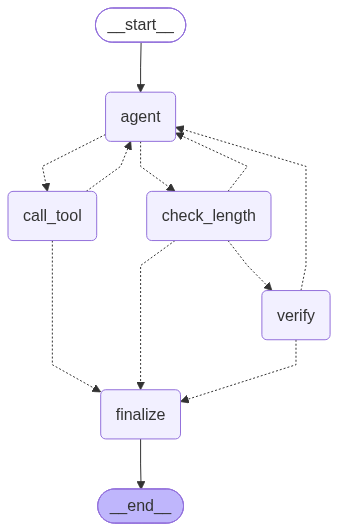

In [9]:
graph

## Testing Sample Questions

In [10]:
#Big Query clean questions
Q1 = """What's the reorder rate by department?"""
Q2 = """What features have the strongest correlation with reorder rate?"""
Q3 = """How many unique products are there? How many unique users? How many unique orders?"""

#DAX clean questions
Q4 = """What is the champion model's Recall at 5 on the test set?"""
Q5 = """Which model is currently the champion model, and what's its total annual profit lift?"""
Q6 = """What's the champion model's Recall@5, and what's the overall reorder rate in the raw order data?"""

#Big Query Table Output

Q7 = """Show me a table of reorder rate by department, sorted highest to lowest."""
Q8 = """Show me a table of the top 10 products by reorder rate, with their department and total orders."""
Q9 = """Break down average basket size and reorder ratio by department."""

#DAX Table Output
Q10 = """List the SHAP feature importance rankings for the XGBoost Ranker model."""

#Big Query Guardrail Questions
Q11 = """List every order ID in the product order analysis table."""
Q12 = """Show me every column for every row in the product order analysis table."""
Q13 = """Show me every column for every row in the candidate reorder features table."""

## Run it end to end

Real Claude calls, real telemetry write - via `astream`, not `ainvoke`, matching the gateway's actual invocation pattern from the start (`.claude/rules/gateway.md`). With only `ping` bound, a simple question goes `agent -> check_length -> verify -> finalize` on the first pass.

In [28]:
initial_state = {
    "question": Q3,
    "conversation_id": str(uuid.uuid4()),
    "user_id": "notebook-test-user",
    "turn_started_at": datetime.now(timezone.utc),
    "filter_context": [],
    "active_page": None,
    "image_base64": None,
    "history_messages": [],
    "messages": [HumanMessage(content=Q3)],
    "tool_calls": [],
    "iteration_count": 0,
    "verification_retry_count": 0,
    "length_retry_count": 0,
    "verified": False,
    "bytes_consumed": 0,
    "prompt_tokens": 0,
    "completion_tokens": 0,
    "llm_calls": 0,
    "errors": [],
    "cancelled": False,
    "needs_approval": False,
    "pending_queries": [],
    "deferred_dax": [],
    "estimated_cost": None,
    "cost_cap_exceeded": False,
    "iteration_cap_hit": False,
    "answer_markdown": "",
    "chart_url": None,
    "sources": [],
}

final_state = None
async for chunk in graph.astream(initial_state, stream_mode=["updates", "values"]):
    kind, data = chunk
    if kind == "values":
        final_state = data
        continue
    node = next(iter(data))
    print(f"-> node ran: {node}")

print()
print("answer_markdown:", final_state["answer_markdown"])
print("verified:", final_state["verified"])
print("llm_calls:", final_state["llm_calls"])
print("prompt_tokens:", final_state["prompt_tokens"])
print("completion_tokens:", final_state["completion_tokens"])
print("message count:", len(final_state["messages"]))
assert final_state["verified"] is True
assert len(final_state["answer_markdown"]) > 0
assert final_state["prompt_tokens"] > 0
assert final_state["completion_tokens"] > 0
print()
print("PASS -- full loop ran agent -> check_length -> verify -> finalize, telemetry written")

-> node ran: agent
-> node ran: call_tool
-> node ran: agent
-> node ran: check_length
-> node ran: verify
-> node ran: finalize

answer_markdown: Based on the order-line data in the warehouse:

| Metric | Count |
|---|---|
| Unique products | 41,681 |
| Unique users | 20,508 |
| Unique orders | 331,329 |

A few natural follow-ups: want the average number of orders per user, the most popular products, or a reorder-rate breakdown by department?
verified: True
llm_calls: 2
prompt_tokens: 36417
completion_tokens: 284
message count: 4

PASS -- full loop ran agent -> check_length -> verify -> finalize, telemetry written


In [29]:
final_state

{'question': 'How many unique products are there? How many unique users? How many unique orders?',
 'conversation_id': '0c33ebd4-4fad-40f0-ae2a-38e7c946c460',
 'user_id': 'notebook-test-user',
 'turn_started_at': datetime.datetime(2026, 9, 25, 0, 40, 45, 361234, tzinfo=datetime.timezone.utc),
 'filter_context': [],
 'active_page': None,
 'image_base64': None,
 'history_messages': [],
 'messages': [HumanMessage(content='How many unique products are there? How many unique users? How many unique orders?', additional_kwargs={}, response_metadata={}, id='2faa8d3c-4a87-4b84-b137-5b62057a79b7'),
  AIMessage(content=[{'signature': 'EqMCCpABCBIYAipArUlbMJuOqvZn6rlUhvg2rslr8UXIfCIckxAIqffr3SClQM/mINwb2b6eze/sMtxXS949TN7LpcmN79Bo4FDW/TIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQzM2Y4NGM0ZS05NGMxLTRiYzgtOWU5OC00MjBjMmI4NmU2MGKoAY2G19UGEgyqcKd0vEdKbxN+REkaDHoiJw81Xt3Wp3ViPCIwoftutPqWpD6ysmIpWiUXEGIkSHOUpxgXX4WE3LeYxcl0AXvbybP6DaIMmVFMXCnYKkCWyCYu/olr3QSuusWDk7rauzC2snzIuMCPmD4xnpI/4IY5fmB2sa882JFwzt0e

In [30]:
display(Markdown(final_state["answer_markdown"]))

Based on the order-line data in the warehouse:

| Metric | Count |
|---|---|
| Unique products | 41,681 |
| Unique users | 20,508 |
| Unique orders | 331,329 |

A few natural follow-ups: want the average number of orders per user, the most popular products, or a reorder-rate breakdown by department?